# **Question 4.2.1**
**Try adding more hidden layers and see how it affects the results.**

Simply increasing the number of hidden layers, while keeping all other parameters constant, will reduce the accuracy.

In [1]:
import torch
from matplotlib.pyplot import legend
from torch import nn
from d2l import torch as d2l

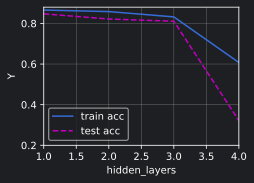

In [5]:
train_iter, test_iter = d2l.load_data_fashion_mnist(256, resize=None, root='../../data')

def initweight4_2_1(num_inputs=784, num_outputs=10, num_hiddens=256, num_hidden_layers=1):
    params = []
    for i in range(num_hidden_layers):
        a = num_inputs if i == 0 else num_hiddens
        b = num_hiddens
        params.append(nn.Parameter(torch.randn(a, b, requires_grad=True) * 0.01))
        params.append(nn.Parameter(torch.zeros(b, requires_grad=True)))
    params.append(nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01))
    params.append(nn.Parameter(torch.zeros(num_outputs, requires_grad=True)))
    return params

show_train = 0
num_inputs = 784
num_outputs = 10
num_hiddens = 256
num_hidden_layers_list = list(range(1, 5))
animatornum_hiddenlayers = d2l.Animator(xlabel='hidden_layers', ylabel='Y', xlim=[num_hidden_layers_list[0], num_hidden_layers_list[-1]], ylim=[0.2, 0.88], legend=['train acc', 'test acc'])

for num_hidden_layers in num_hidden_layers_list:
    num_epochs, lr = 10, 0.1
    loss = nn.CrossEntropyLoss(reduction='none')
    params = initweight4_2_1(num_inputs, num_outputs, num_hiddens, num_hidden_layers)
    updater = torch.optim.SGD(params, lr)

    def relu(X):
        a = torch.zeros_like(X)
        return torch.max(X, a)

    def net(X):
        X = X.reshape(-1, num_inputs)
        H = relu(X@params[0] + params[1])
        for i in range(2, 2 * num_hidden_layers, 2):
            H = relu(H@params[i] + params[i + 1])
        return (H@params[-2] + params[-1])

    if show_train == 1:
        animator = d2l.Animator(xlabel=f'epoch num_hidden_layers:{num_hidden_layers}', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.9], legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        train_metrics = d2l.train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = d2l.evaluate_accuracy(net, test_iter)
        if show_train == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))

    train_loss, train_acc = train_metrics
    print(f'num_hiddenlayers={num_hidden_layers},train_loss={train_loss}, train_acc={train_acc},test_acc={test_acc}')
    animatornum_hiddenlayers.add(num_hidden_layers,(train_acc,test_acc))

# **Question 4.2.2**
**With all other parameters held constant, change the value of the hyperparameter `num_hiddens` and observe how changes to this hyperparameter affect the results. Determine the optimal value for this hyperparameter.**

In [6]:
def initweight4_2_2(num_inputs=784, num_outputs=10, num_hiddens=256):
    W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
    b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
    W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
    b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
    params = [W1, b1, W2, b2]
    return W1,b1,W2,b2, params

KeyboardInterrupt: 

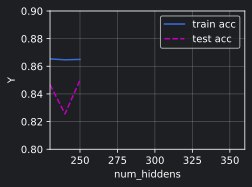

In [7]:
show_train=0
num_inputs=784
num_outputs=10
num_hiddens_list=list(range(230,370,10))
animator_num_hiddens = d2l.Animator(xlabel='num_hiddens',ylabel='Y',xlim=[num_hiddens_list[0],num_hiddens_list[-1]], ylim=[0.8, 0.9],
                        legend=[ 'train acc', 'test acc'])

for num_hiddens in num_hiddens_list:
    num_epochs, lr = 10, 0.1
    loss = nn.CrossEntropyLoss(reduction='none')
    W1, b1, W2, b2, params = initweight4_2_2(num_inputs, num_outputs, num_hiddens)
    updater = torch.optim.SGD(params, lr)
    def relu(X):
        a = torch.zeros_like(X)
        return torch.max(X, a)
    def net(X):
        X = X.reshape((-1, num_inputs))
        H = relu(X@W1 + b1)
        return (H@W2 + b2)
    if show_train == 1:
        animator = d2l.Animator(xlabel=f'epoch num_hiddens:{num_hiddens}', ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.9], legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = d2l.train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = d2l.evaluate_accuracy(net, test_iter)
        if show_train == 1:
            animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    print(f'num_hiddens={num_hiddens}, train_loss={train_loss}, train_acc={train_acc},test_acc={test_acc}')
    animator_num_hiddens.add(num_hiddens, (train_acc,test_acc))
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

# **Question 4.2.3**
**How does changing the learning rate affect the results? Keeping the model architecture and other hyperparameters (including the number of epochs) constant, what learning rate setting yields the best results?**<br><br>
A higher learning rate can reduce the loss more quickly and train the model faster in the early stages, but it may also cause parameter updates to be too large, resulting in the parameters oscillating around the optimal solution—failing to converge or converging to an incorrect value. Conversely, a learning rate that is too low will require more training iterations to achieve convergence. The ideal learning rate is not a fixed value, but rather a value that decays as training progresses—that is, the learning rate is relatively high in the early stages of training and gradually decreases as training continues until the model converges.

In [ ]:
list_lr = [1.0,0.1,0.01,0.001]
num_epochs = 20
d2l.plt.figure(figsize=(10,10))

for lr in list_lr:
    num_intputs, num_outputs, nums_hiddens = 784, 10, 256
    W1, b1, W2, b2, params = initweight4_2_2(num_inputs, num_outputs, num_hiddens)
    updater = torch.optim.SGD(params, lr)
    epoch_loss=[]
    def relu(X):
        a = torch.zeros_like(X)
        return torch.max(X, a)
    def net(X):
        X = X.reshape((-1, num_inputs))
        H = relu(X@W1 + b1)
        return (H@W2 + b2)

    for epoch in range(num_epochs):
        train_metrics = d2l.train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = d2l.evaluate_accuracy(net, test_iter)
        epoch_loss.append(train_metrics[0])

    train_loss, train_acc = train_metrics
    d2l.plt.plot(range(1,num_epochs+1), epoch_loss,label= (f'lr={lr}') )

# **Question 4.2.4**
**What are the best results that can be achieved by jointly optimizing all hyperparameters (learning rate, number of epochs, number of hidden layers, and number of hidden units per layer)?**

epochs=10,num_hiddens=256,lr=0.1,batch_size=32,train_loss=0.38276306432088214, train_acc=0.8633,test_acc=0.8484


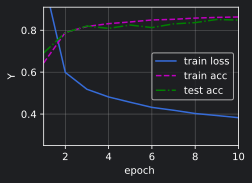

In [10]:
num_inputs,num_outputs,num_hiddens=784,10,256
num_epochs, lr, batch_size = 10, 0.1, 32
loss = nn.CrossEntropyLoss(reduction='none')
W1,b1,W2,b2, params=initweight4_2_2(num_inputs=num_inputs, num_outputs=num_outputs, num_hiddens=num_hiddens)
updater = torch.optim.SGD(params, lr=lr)
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)  # 这里“@”代表矩阵乘法
    return (H@W2 + b2)
animator = d2l.Animator(xlabel=f'epoch ',ylabel='Y', xlim=[1, num_epochs], ylim=[0.25, 0.91],
                legend=['train loss', 'train acc', 'test acc'])
for epoch in range(num_epochs):
    train_metrics = d2l.train_epoch_ch3(net, train_iter, loss,   updater)
    test_acc = d2l.evaluate_accuracy(net, test_iter)

    animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
assert train_loss < 0.5, train_loss
assert train_acc <= 1 and train_acc > 0.7, train_acc
assert test_acc <= 1 and test_acc > 0.7, test_acc
print(f'epochs={num_epochs},num_hiddens={num_hiddens},lr={lr},batch_size={batch_size},train_loss={train_loss}, train_acc={train_acc},test_acc={test_acc}')

# **Question 4.2.5**
**Explain why it is more challenging when multiple hyperparameters are involved.**<br><br>
Hyperparameters cannot be determined using conventional optimization methods. Since each adjustment must be based on training results, the cost of making such adjustments is high, and an excessive number of hyperparameters leads to a greater number of parameter combinations, making it difficult to determine the optimal hyperparameters through training.

# **Question 4.2.6**
**If you want to develop a search method for multiple hyperparameters, come up with a clever strategy.**<br><br>
Hyperparameters cannot be determined through conventional optimization methods. Adjusting hyperparameters based on training results each time incurs significant costs, and an excessive number of hyperparameters leads to a larger number of parameter combinations, making it difficult to determine the optimal hyperparameters through training. Select a set of hyperparameters based on past experience (from the literature or previous practice). Start by determining the value of the parameter associated with the lowest computational cost after adjustment, then move on to the parameter with a slightly higher computational cost. Determine one hyperparameter at a time until all hyperparameter values are established. Repeat this process until satisfactory results are achieved.